<a href="https://colab.research.google.com/github/ruhmmachaudhary-rgb/AI-ML-Fellowship-GDGOC-Atk/blob/main/week5/logistic-regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Accuracy (From Scratch): 1.000


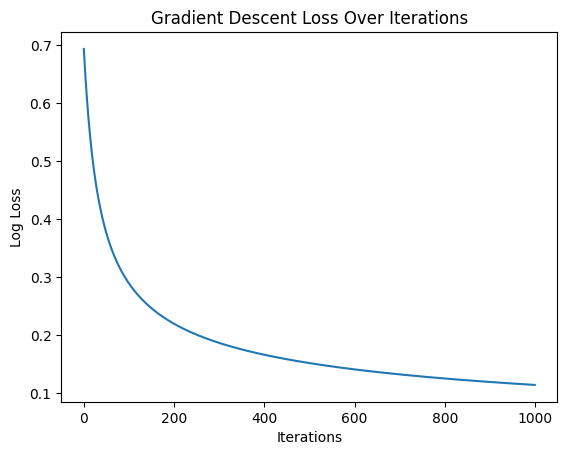

Accuracy (Scikit-Learn): 1.000
Confusion Matrix - Scratch:
 [[21  0]
 [ 0 19]]
Confusion Matrix - Scikit-Learn:
 [[21  0]
 [ 0 19]]


In [1]:

# Week 5: Logistic Regression & Gradient Descent

"""
Logistic Regression is a supervised learning algorithm used for binary classification.
Instead of predicting continuous values, it predicts probabilities of class membership.

Math behind Logistic Regression:
1. Linear combination: z = w1*x1 + w2*x2 + ... + b
2. Sigmoid function: σ(z) = 1 / (1 + e^(-z))
   - Maps any real number to [0,1], representing probability
3. Prediction: Class 1 if σ(z) >= 0.5, Class 0 if σ(z) < 0.5
4. Loss function: Binary Cross-Entropy (Log Loss)
   L = -(1/n) * Σ [y*log(y_pred) + (1-y)*log(1-y_pred)]
5. Optimize weights using Gradient Descent
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

np.random.seed(42)
X = np.random.randn(200, 2)
y = (X[:, 0] + X[:, 1] > 0).astype(int).reshape(-1,1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class LogisticRegressionScratch:
    def __init__(self, lr=0.1, n_iters=1000):
        self.lr = lr
        self.n_iters = n_iters
        self.w = None
        self.b = None
        self.loss_history = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def compute_loss(self, y, y_pred):
        n_samples = y.shape[0]
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        loss = -(1/n_samples) * np.sum(y*np.log(y_pred) + (1-y)*np.log(1-y_pred))
        return loss

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros((n_features, 1))
        self.b = 0

        for i in range(self.n_iters):
            linear_model = X @ self.w + self.b
            y_pred = self.sigmoid(linear_model)
            dw = (1/n_samples) * X.T @ (y_pred - y)
            db = (1/n_samples) * np.sum(y_pred - y)
            self.w -= self.lr * dw
            self.b -= self.lr * db
            loss = self.compute_loss(y, y_pred)
            self.loss_history.append(loss)

    def predict_prob(self, X):
        return self.sigmoid(X @ self.w + self.b)

    def predict(self, X):
        probs = self.predict_prob(X)
        return (probs >= 0.5).astype(int)

model_scratch = LogisticRegressionScratch(lr=0.1, n_iters=1000)
model_scratch.fit(X_train, y_train)
y_pred_scratch = model_scratch.predict(X_test)

acc_scratch = accuracy_score(y_test, y_pred_scratch)
print(f"Accuracy (From Scratch): {acc_scratch:.3f}")

plt.plot(model_scratch.loss_history)
plt.xlabel("Iterations")
plt.ylabel("Log Loss")
plt.title("Gradient Descent Loss Over Iterations")
plt.show()

sk_model = LogisticRegression()
sk_model.fit(X_train, y_train.ravel())
y_pred_sk = sk_model.predict(X_test)

acc_sk = accuracy_score(y_test, y_pred_sk)
print(f"Accuracy (Scikit-Learn): {acc_sk:.3f}")

cm_scratch = confusion_matrix(y_test, y_pred_scratch)
cm_sk = confusion_matrix(y_test, y_pred_sk)

print("Confusion Matrix - Scratch:\n", cm_scratch)
print("Confusion Matrix - Scikit-Learn:\n", cm_sk)